# Goal Success Classification Training
Train a RandomForest classifier on synthetic goal data and report metrics.

In [21]:
# ============================================================
# Import necessary libraries for modeling and evaluation
# ============================================================

import pandas as pd
import numpy as np

# Model
from sklearn.ensemble import RandomForestClassifier

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# ============================================================
# Load the synthetic financial dataset
# ============================================================

df = pd.read_csv("synthetic_goal_training.csv")

# Display basic dataset info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (165000, 26)


,user_id,month,goal_start_month,deadline_month,target_amount,current_amount,remaining_amount,months_left,required_monthly,prev3_avg_savings,...,prev3_expense_ratio,prev3_income_std,prev3_expense_std,prev3_savings_std,lag1_savings,lag2_savings,month_num,month_sin,month_cos,target_savings_ratio
0,USER0001,2022-04,2024-05,2024-12,18971.433447,3794.286689,15177.146757,32,474.285836,1432.740713,...,0.395702,152.388265,106.537967,256.687775,1422.138485,1752.284751,4,8.660254e-01,-0.500000,0.307885
1,USER0001,2022-05,2024-05,2024-12,18971.433447,3794.286689,15177.146757,31,489.585379,1484.111775,...,0.410368,898.318304,1044.060230,198.557922,1277.912088,1422.138485,5,5.000000e-01,-0.866025,0.540732
2,USER0001,2022-06,2024-05,2024-12,18971.433447,3794.286689,15177.146757,30,505.904892,1779.878215,...,0.403822,954.140731,873.341618,610.748684,2639.584071,1277.912088,6,1.224647e-16,-1.000000,0.194388
3,USER0001,2022-07,2024-05,2024-12,18971.433447,3794.286689,15177.146757,29,523.349888,1663.276612,...,0.409205,1102.659026,860.323393,695.436463,1072.333677,2639.584071,7,-5.000000e-01,-0.866025,0.356060
4,USER0001,2022-08,2024-05,2024-12,18971.433447,3794.286689,15177.146757,28,542.040956,1879.565890,...,0.383199,978.243674,362.770090,640.697705,1926.779923,1072.333677,8,-8.660254e-01,-0.500000,0.073207


In [23]:
# ============================================================
# Define binary goal success label
# ============================================================

# A goal is considered successful if projected savings
# (average savings × months remaining) covers remaining goal amount

df["goal_success"] = (
    df["prev3_avg_savings"] * df["months_left"]
    >= df["remaining_amount"]
).astype(int)

# Check class distribution
df["goal_success"].value_counts()

goal_success
0    94478
1    70522
Name: count, dtype: int64

In [25]:
# ============================================================
# Select model features
# ============================================================

# IMPORTANT:
# We intentionally remove:
# - remaining_amount
# - required_monthly
# Because they directly determine the target (leakage risk)

FEATURES = [
    "months_left",
    "prev3_avg_savings",
    "prev3_std_savings",
    "prev3_trend",
    "prev3_avg_income",
    "prev3_avg_expense",
    "prev3_income_std",
    "prev3_expense_std",
    "lag1_savings",
    "lag2_savings",
    "target_savings_ratio",
    "month_sin",
    "month_cos"
]

X = df[FEATURES]
y = df["goal_success"]

print("Features used:", FEATURES)

Features used: ['months_left', 'prev3_avg_savings', 'prev3_std_savings', 'prev3_trend', 'prev3_avg_income', 'prev3_avg_expense', 'prev3_income_std', 'prev3_expense_std', 'lag1_savings', 'lag2_savings', 'target_savings_ratio', 'month_sin', 'month_cos']


In [26]:
# ============================================================
# Split dataset into training and testing sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80% training, 20% testing
    random_state=42,        # Reproducibility
    stratify=y              # Maintain class balance
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (132000, 13)
Testing set size: (33000, 13)


In [27]:
# ============================================================
# Train Random Forest classifier
# ============================================================

clf = RandomForestClassifier(
    n_estimators=200,       # Number of trees
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

Explanation:
Random Forest is chosen because:

Handles nonlinear relationships

Robust to skewed distributions

Tolerates correlated features

Requires no scaling

In [28]:
# ============================================================
# Evaluate model performance
# ============================================================

# Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     18896
           1       0.90      0.92      0.91     14104

    accuracy                           0.92     33000
   macro avg       0.92      0.92      0.92     33000
weighted avg       0.92      0.92      0.92     33000

ROC-AUC Score: 0.9816916628284
Confusion Matrix:
[[17478  1418]
 [ 1079 13025]]


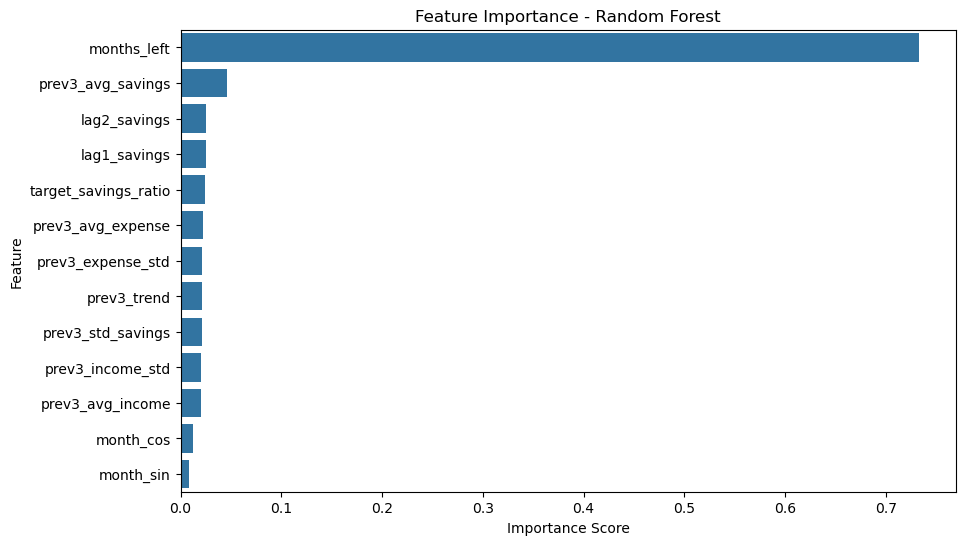

,feature,importance
0,months_left,0.732603
1,prev3_avg_savings,0.045851
9,lag2_savings,0.025426
8,lag1_savings,0.025254
10,target_savings_ratio,0.024184
5,prev3_avg_expense,0.021942
7,prev3_expense_std,0.021375
3,prev3_trend,0.021278
2,prev3_std_savings,0.020863
6,prev3_income_std,0.020604


In [29]:
# ============================================================
# Analyze feature importance
# ============================================================

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": clf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

feature_importance

Overall Interpretation

The model tells:

Time remaining (deadline pressure) is the dominant factor.

Recent savings behavior is the second most important factor.

Stability and consistency matter moderately.

Seasonality has minimal effect.

| Feature                   | Meaning                                                 |
| ------------------------- | ------------------------------------------------------- |
| **months_left**           | Number of months remaining until the goal deadline      |
| **prev3_avg_savings**     | Average savings over the last 3 months                  |
| **prev3_std_savings**     | Volatility of savings over last 3 months                |
| **prev3_trend**           | Direction of savings change (increasing/decreasing)     |
| **prev3_avg_income**      | Average income over last 3 months                       |
| **prev3_avg_expense**     | Average expenses over last 3 months                     |
| **prev3_income_std**      | Income variability over last 3 months                   |
| **prev3_expense_std**     | Expense variability over last 3 months                  |
| **lag1_savings**          | Savings in previous month                               |
| **lag2_savings**          | Savings two months ago                                  |
| **target_savings_ratio**  | Required monthly savings relative to income             |
| **month_sin / month_cos** | Cyclical encoding of month (seasonality representation) |


In [30]:
# ============================================================
# Cross-Validation Setup
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

In [31]:
# ============================================================
# Define 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [32]:
# ============================================================
# Cross-Validation - Accuracy
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

cv_accuracy = cross_val_score(
    rf_model,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-Validation Accuracy Scores:", cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())
print("Std Deviation:", cv_accuracy.std())

Cross-Validation Accuracy Scores: [0.92615152 0.9240303  0.92454545 0.92563636 0.92390909]
Mean Accuracy: 0.9248545454545454
Std Deviation: 0.0008901872977978909


In [33]:
# ============================================================
# Cross-Validation - ROC AUC
# ============================================================

cv_auc = cross_val_score(
    rf_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-Validation ROC-AUC Scores:", cv_auc)
print("Mean ROC-AUC:", cv_auc.mean())
print("Std Deviation:", cv_auc.std())

Cross-Validation ROC-AUC Scores: [0.98180297 0.98173302 0.98178314 0.98229569 0.98207021]
Mean ROC-AUC: 0.9819370053671834
Std Deviation: 0.00021431223423069477


A 5-fold stratified cross-validation confirmed model robustness, yielding a mean accuracy of 92.48% and mean ROC-AUC of 0.9819 with minimal variance across folds. The low standard deviation indicates stable and consistent generalization performance.